In [ ]:
!pip install --quiet torch torchvision albumentations==1.3.0 opencv-python matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.5/123.5 kB 6.0 MB/s eta 0:00:00


In [ ]:
import os, cv2, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# 2) Kaggle download (run in Colab). Upload your kaggle.json when prompted.
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sasiprabhakr","key":"d034871ac0b3bfb8345c9c987875c3a9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d iamtapendu/chest-x-ray-lungs-segmentation -p /content/datasets --unzip

!kaggle datasets download -d andrewmvd/liver-tumor-segmentation \
    -p /content/datasets/ct --unzip

!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation \
    -p /content/datasets/mri --unzip

Dataset URL: https://www.kaggle.com/datasets/iamtapendu/chest-x-ray-lungs-segmentation
License(s): apache-2.0
100% 3.59G/3.59G [01:05<00:00, 88.9MB/s]
100% 3.59G/3.59G [01:05<00:00, 58.6MB/s]
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/liver-tumor-segmentation
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 99% 4.77G/4.84G [02:11<00:03, 18.1MB/s]
100% 4.84G/4.84G [02:11<00:00, 39.6MB/s]
Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
 95% 679M/714M [00:08<00:00, 65.0MB/s]
100% 714M/714M [00:10<00:00, 74.7MB/s]


In [ ]:
!ls /content/datasets/xray

ls: cannot access '/content/datasets/xray': No such file or directory


Images found: 704
Masks found: 704


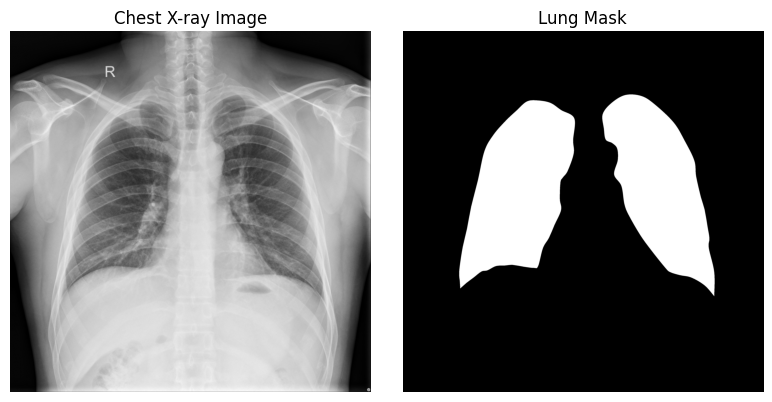

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Correct chest X-ray paths
img_dir = "/content/datasets/Chest-X-Ray/Chest-X-Ray/image"
mask_dir = "/content/datasets/Chest-X-Ray/Chest-X-Ray/mask"

# List files safely
images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.png','.jpg','.jpeg'))])
masks  = sorted([f for f in os.listdir(mask_dir) if f.endswith(('.png','.jpg','.jpeg'))])

print("Images found:", len(images))
print("Masks found:", len(masks))

# Safety checks
if len(images) == 0 or len(masks) == 0:
    raise ValueError("❌ Images or masks folder is empty. Check paths!")

# Pick first image
img_name = images[0]

# Read image & corresponding mask
img = cv2.imread(os.path.join(img_dir, img_name), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(os.path.join(mask_dir, img_name), cv2.IMREAD_GRAYSCALE)

if img is None or mask is None:
    raise ValueError("❌ Image or mask not loaded. Name mismatch!")

# Display
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Chest X-ray Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Lung Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

IMG_SIZE = 256

def preprocess(img, mask):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0
    mask = mask / 255.0
    mask = (mask > 0.5).astype(np.float32)

    return img, mask

In [ ]:
img = cv2.imread(os.path.join(img_dir, images[0]), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(os.path.join(mask_dir, images[0]), cv2.IMREAD_GRAYSCALE)

img_p, mask_p = preprocess(img, mask)

print(img_p.shape, mask_p.shape)
print("Image min/max:", img_p.min(), img_p.max())
print("Mask unique values:", np.unique(mask_p))

(256, 256) (256, 256)
Image min/max: 0.0 1.0
Mask unique values: [0. 1.]


In [ ]:
import torch
from torch.utils.data import Dataset

class LungDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img = cv2.imread(os.path.join(self.img_dir, img_name), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(self.mask_dir, img_name), cv2.IMREAD_GRAYSCALE)

        img, mask = preprocess(img, mask)

        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [ ]:
dataset = LungDataset(img_dir, mask_dir)

print("Dataset length:", len(dataset))

from torch.utils.data import DataLoader
loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

Dataset length: 704


In [ ]:
imgs, masks = next(iter(loader))
print(imgs.shape, masks.shape)

torch.Size([2, 1, 256, 256]) torch.Size([2, 1, 256, 256])


In [ ]:
import torch
import torch.nn as nn

# U-Net Architecture (simplified for demonstration)
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(UNet, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.upconv4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    print(f"\nEpoch {epoch+1}/{EPOCHS} started")

    for batch_idx, (imgs, masks) in enumerate(loader):
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Debug print (so you SEE progress)
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} finished | Avg Loss: {epoch_loss/len(loader):.4f}")

Using device: cuda

Epoch 1/3 started
  Batch 0, Loss: 0.7148
  Batch 10, Loss: 0.5224
  Batch 20, Loss: 0.2737
  Batch 30, Loss: 0.2244
  Batch 40, Loss: 0.2043


KeyboardInterrupt: 

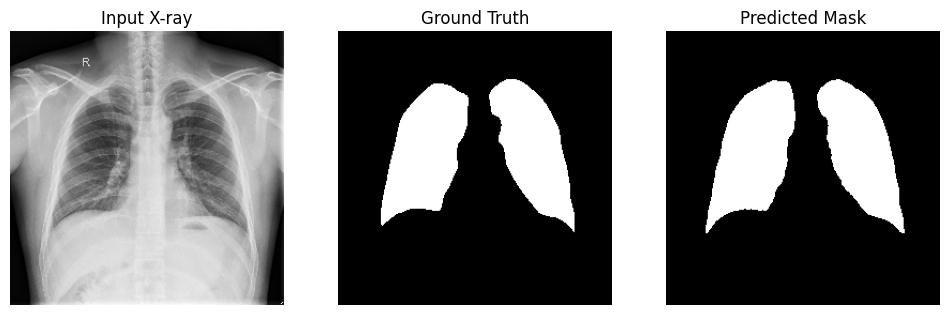

In [ ]:
model.eval()

with torch.no_grad():
    img, mask = dataset[0]
    img = img.unsqueeze(0).to(device)

    pred = torch.sigmoid(model(img))[0,0].cpu().numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img[0,0].cpu(), cmap="gray")
plt.title("Input X-ray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask[0], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [ ]:
def dice_score(pred, target):
    pred = (pred > 0.5).float()
    smooth = 1e-6
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

In [ ]:
# Re-fetch the original mask from the LungDataset, as it might have been overwritten
_, chest_xray_mask = dataset[0] # This mask is a torch.Tensor (1, 256, 256)

dice = dice_score(torch.tensor(pred), chest_xray_mask[0])
print("Dice score:", dice.item())

Dice score: 0.9729364514350891


🟢 MRI SEGMENTATION

In [ ]:
!pip install nibabel

In [ ]:
import os
import cv2
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
import os

root = "/content/datasets/mri/kaggle_3m"
patients = os.listdir(root)

print("Number of patients:", len(patients))
print("First patient folder:", patients[0])
print("Files inside:")

print(os.listdir(os.path.join(root, patients[0])))

Number of patients: 112
First patient folder: TCGA_HT_7693_19950520
Files inside:
['TCGA_HT_7693_19950520_17.tif', 'TCGA_HT_7693_19950520_20_mask.tif', 'TCGA_HT_7693_19950520_10_mask.tif', 'TCGA_HT_7693_19950520_18.tif', 'TCGA_HT_7693_19950520_9.tif', 'TCGA_HT_7693_19950520_14_mask.tif', 'TCGA_HT_7693_19950520_6.tif', 'TCGA_HT_7693_19950520_6_mask.tif', 'TCGA_HT_7693_19950520_21.tif', 'TCGA_HT_7693_19950520_10.tif', 'TCGA_HT_7693_19950520_12.tif', 'TCGA_HT_7693_19950520_15_mask.tif', 'TCGA_HT_7693_19950520_9_mask.tif', 'TCGA_HT_7693_19950520_8.tif', 'TCGA_HT_7693_19950520_2_mask.tif', 'TCGA_HT_7693_19950520_7_mask.tif', 'TCGA_HT_7693_19950520_4_mask.tif', 'TCGA_HT_7693_19950520_15.tif', 'TCGA_HT_7693_19950520_14.tif', 'TCGA_HT_7693_19950520_4.tif', 'TCGA_HT_7693_19950520_13_mask.tif', 'TCGA_HT_7693_19950520_3_mask.tif', 'TCGA_HT_7693_19950520_18_mask.tif', 'TCGA_HT_7693_19950520_3.tif', 'TCGA_HT_7693_19950520_19.tif', 'TCGA_HT_7693_19950520_16.tif', 'TCGA_HT_7693_19950520_11_mask.tif',

In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

IMG_SIZE = 256

class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []

        for patient in os.listdir(root_dir):
            patient_path = os.path.join(root_dir, patient)
            if not os.path.isdir(patient_path):
                continue

            files = os.listdir(patient_path)

            images = [f for f in files if f.endswith(".tif") and "_mask" not in f]

            for img_name in images:
                mask_name = img_name.replace(".tif", "_mask.tif")
                if mask_name in files:
                    self.samples.append((
                        os.path.join(patient_path, img_name),
                        os.path.join(patient_path, mask_name)
                    ))

        print("✅ Total MRI slices:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0
        mask = (mask > 0).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

mri_dataset = MRIDataset("/content/datasets/mri/kaggle_3m")

mri_loader = DataLoader(
    mri_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

✅ Total MRI slices: 3929


In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

IMG_SIZE = 256

class MRIDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []

        for patient in os.listdir(root_dir):
            patient_path = os.path.join(root_dir, patient)
            if not os.path.isdir(patient_path):
                continue

            files = os.listdir(patient_path)

            images = [f for f in files if f.endswith(".tif") and "_mask" not in f]

            for img_name in images:
                mask_name = img_name.replace(".tif", "_mask.tif")
                if mask_name in files:
                    self.samples.append((
                        os.path.join(patient_path, img_name),
                        os.path.join(patient_path, mask_name)
                    ))

        print("✅ Total MRI slices:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0
        mask = (mask > 0).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [ ]:
from torch.utils.data import DataLoader

mri_dataset = MRIDataset("/content/datasets/mri/kaggle_3m")

mri_loader = DataLoader(
    mri_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

✅ Total MRI slices: 3929


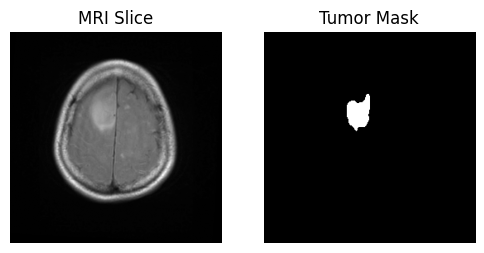

In [ ]:
img, mask = mri_dataset[0]

import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img[0], cmap="gray")
plt.title("MRI Slice")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask[0], cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for batch_idx, (imgs, masks) in enumerate(mri_loader):
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1} Batch {batch_idx}, Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1}, Avg Loss: {epoch_loss/len(mri_loader):.4f}")


Epoch 1 Batch 0, Loss: 0.0214
Epoch 1 Batch 20, Loss: 0.0403
Epoch 1 Batch 40, Loss: 0.0704
Epoch 1 Batch 60, Loss: 0.0372
Epoch 1 Batch 80, Loss: 0.0130
Epoch 1 Batch 100, Loss: 0.0862
Epoch 1 Batch 120, Loss: 0.0173
Epoch 1 Batch 140, Loss: 0.0371
Epoch 1 Batch 160, Loss: 0.0263
Epoch 1 Batch 180, Loss: 0.0474


In [ ]:
model.eval()

with torch.no_grad():
    img, mask = mri_dataset[10]
    img = img.unsqueeze(0).to(device)

    pred = torch.sigmoid(model(img))
    pred = pred.squeeze().cpu().numpy()

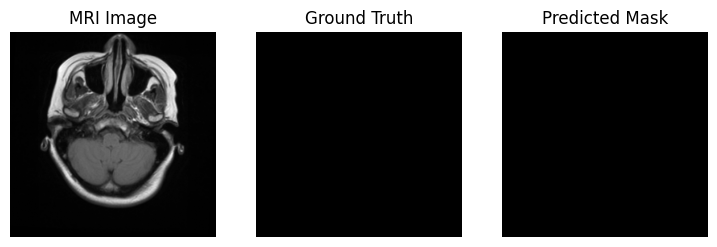

In [ ]:
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(img.cpu()[0][0], cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask[0], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap="grey")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

🟢 CT SEGMENTATION

In [ ]:
import os

ct_root = "/content/datasets/ct"

print("Folders:", os.listdir(ct_root))

sample = os.listdir(os.path.join(ct_root, os.listdir(ct_root)[0]))
print("Sample files:", sample)

Folders: ['segmentations', 'volume_pt4', 'volume_pt3', 'volume_pt2', 'volume_pt1', 'volume_pt5']
Sample files: ['segmentation-53.nii', 'segmentation-68.nii', 'segmentation-65.nii', 'segmentation-39.nii', 'segmentation-43.nii', 'segmentation-88.nii', 'segmentation-61.nii', 'segmentation-80.nii', 'segmentation-75.nii', 'segmentation-78.nii', 'segmentation-70.nii', 'segmentation-24.nii', 'segmentation-44.nii', 'segmentation-120.nii', 'segmentation-28.nii', 'segmentation-36.nii', 'segmentation-64.nii', 'segmentation-40.nii', 'segmentation-122.nii', 'segmentation-112.nii', 'segmentation-94.nii', 'segmentation-3.nii', 'segmentation-116.nii', 'segmentation-129.nii', 'segmentation-5.nii', 'segmentation-42.nii', 'segmentation-74.nii', 'segmentation-25.nii', 'segmentation-60.nii', 'segmentation-11.nii', 'segmentation-16.nii', 'segmentation-13.nii', 'segmentation-45.nii', 'segmentation-17.nii', 'segmentation-69.nii', 'segmentation-14.nii', 'segmentation-54.nii', 'segmentation-114.nii', 'segmentat